In [1]:
import pandas as pd # Data manipulation and analysis
import numpy as np # Numerical operations
import matplotlib.pyplot as plt # Basic data visualization
import seaborn as sns # Advanced statistical visualization
from sklearn.model_selection import train_test_split # Splitting data into train/test sets
from xgboost import XGBRegressor # The Machine Learning model
from sklearn import metrics # Evaluating model performance

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the datasets
calories = pd.read_csv('calories.csv')
exercise = pd.read_csv('exercise.csv')

# Merge the two dataframes on 'User_ID' column
df = pd.merge(exercise, calories, on='User_ID')

# Preview the combined dataframe
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190,94,29,105,40.8,231
1,14861698,female,20,166,60,14,94,40.3,66
2,11179863,male,69,179,79,5,88,38.7,26
3,16180408,female,34,179,71,13,100,40.5,71
4,17771927,female,27,154,58,10,81,39.8,35


In [8]:
# Convert categorical 'Gender' to numerical
df.replace({'Gender': {'male': 0, 'female': 1}}, inplace=True)

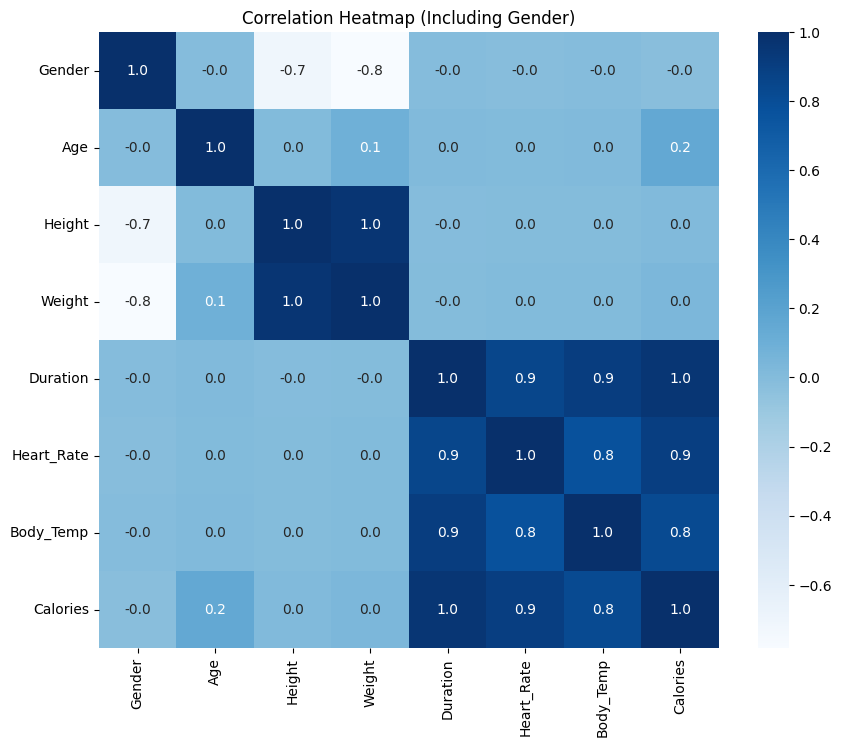

In [10]:
# Select numerical columns (Excluding User_ID)
# User_ID is still there, we only exclude it from the plot
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['User_ID']).corr(), annot=True, fmt='.1f', cmap='Blues')
plt.title('Correlation Heatmap (Including Gender)')
plt.show()

وهنا بعد ما استخدمنا correlation عشان نقدر نفهم علاقة الداتا ببعضها اكتشفنا انه مش مناسب خالص مع النوع ده من الداتا لانه بيناسب اكتر الداتا الخطية وهنا الداتا ممكن عامل يأثر علي عامل  تاني بشكل غير مباشر مثا النوع بيأثر علي الحرق بشكل غير مباشر فمش شرط مدة التمرين بس او  ضربات القلب السريعة هي اللي بتحدد فبنختار حاجه تانيه توضحلنا 


الطريقة اللي جايه دي شبه السكاتر بلوت بس علي اكبر شوية لامه كل الخصائص

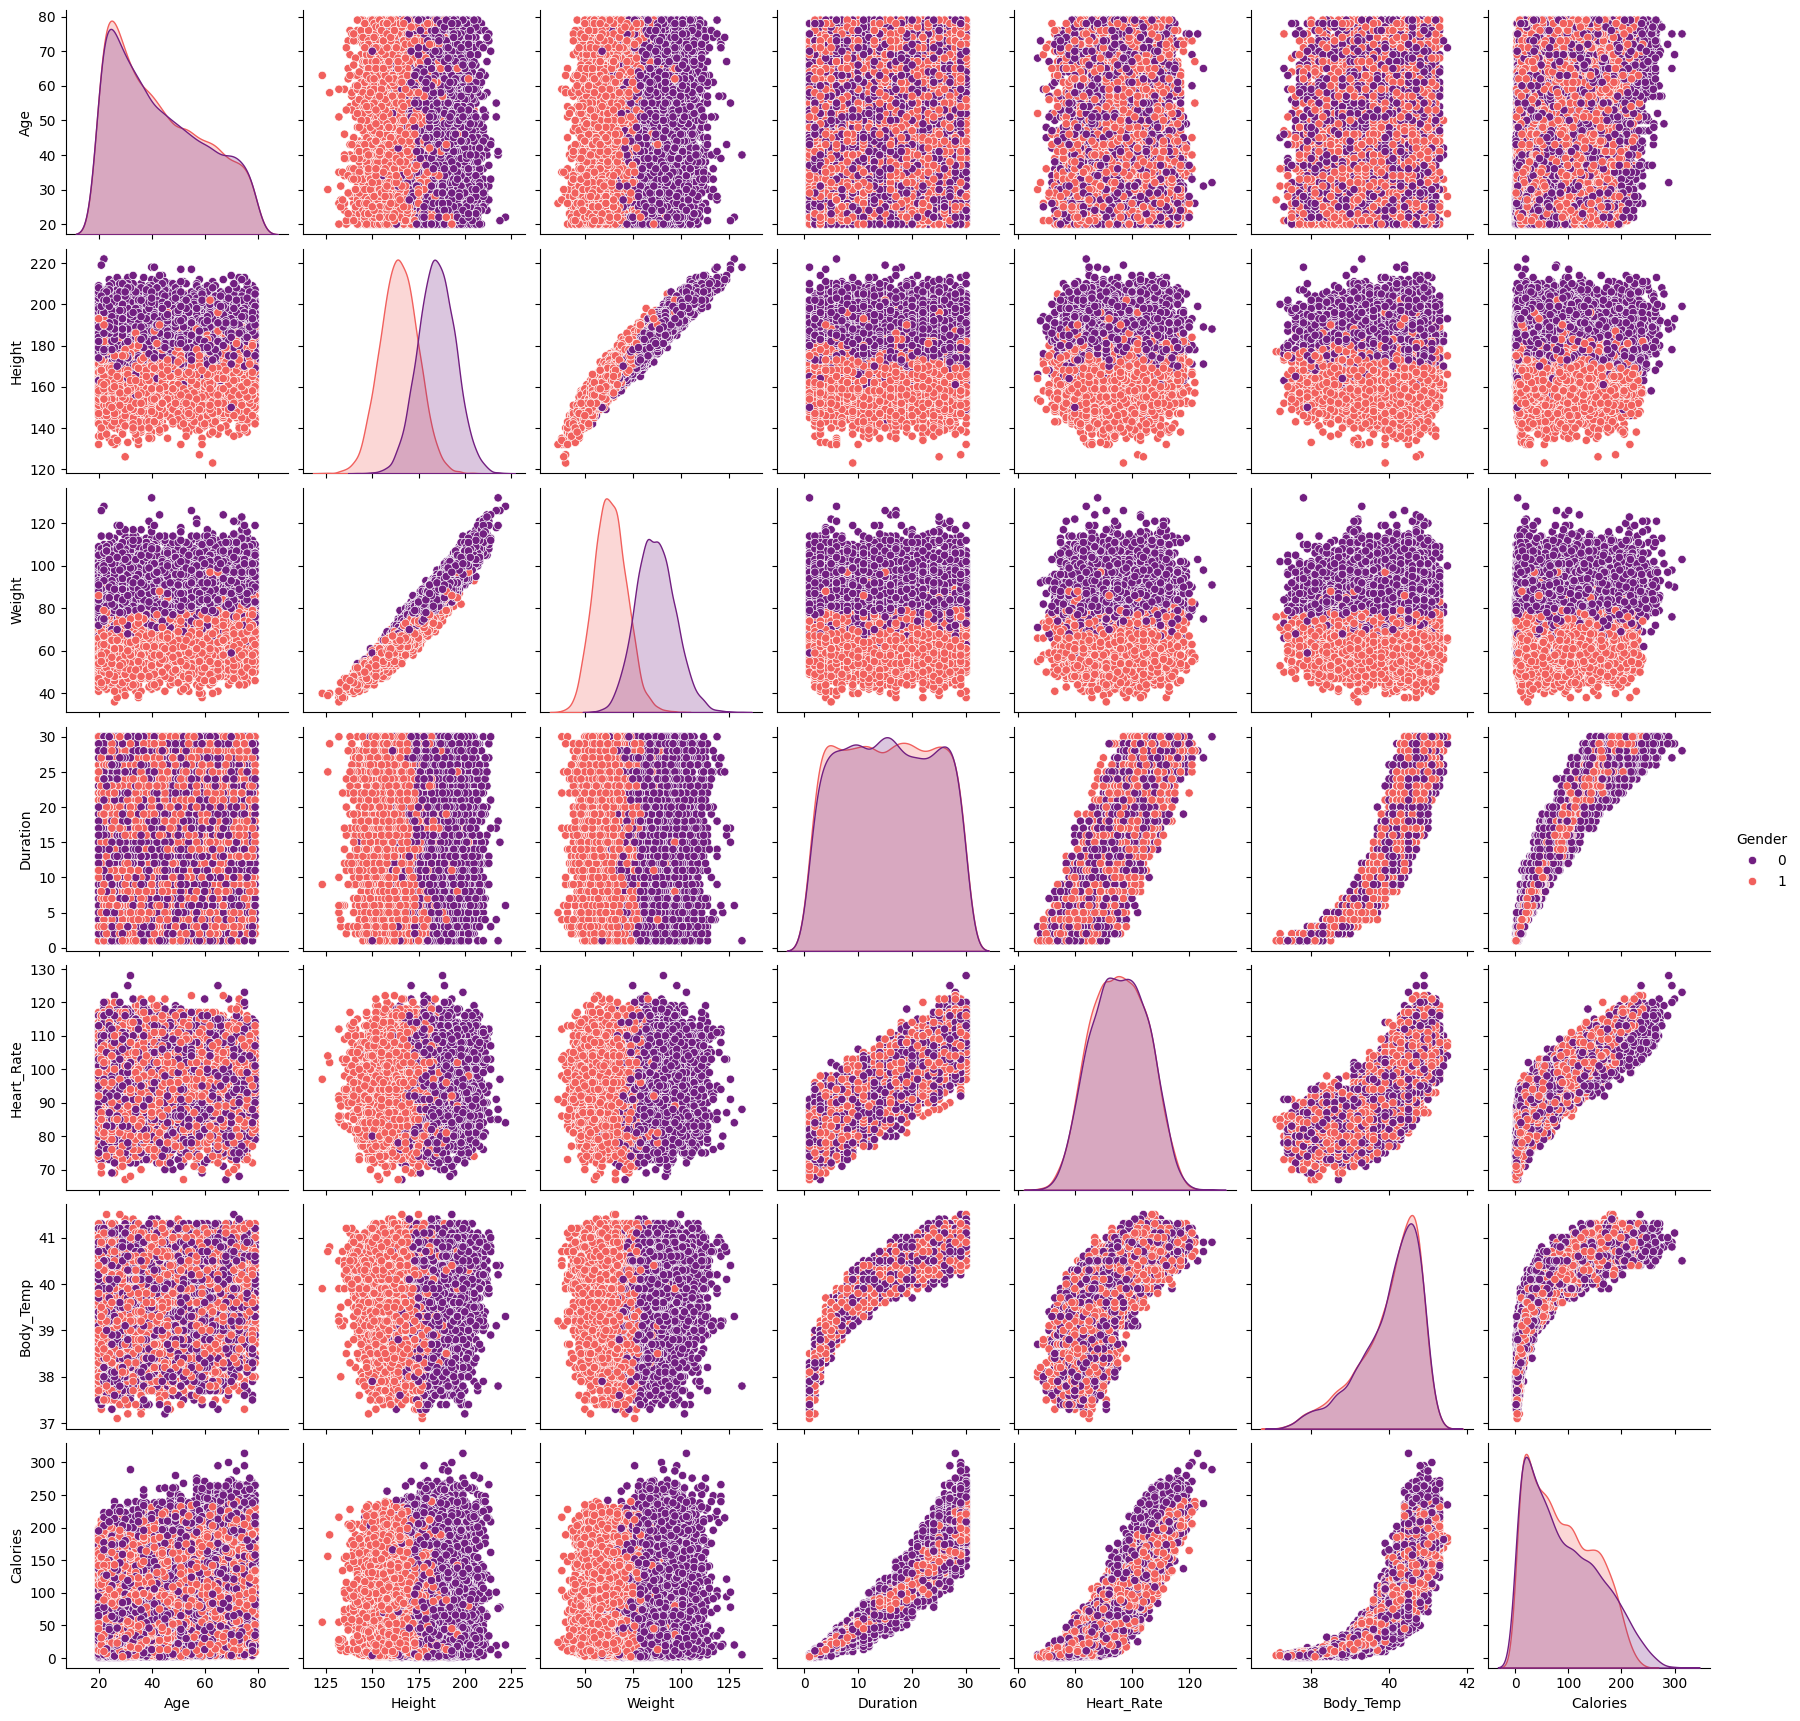

In [12]:
# Visualize relationships between all features
# standard way to explore multiple variables
# Add Gender as a color dimension (Hue)
sns.pairplot(df.drop(columns=['User_ID']), hue='Gender', palette='magma')
plt.show()

In [13]:
# 1. Final check for missing values
print("Checking for missing values...")
print(df.isnull().sum())

# 2. Convert Gender to numerical (we already did this, but keeping it here for consistency)
# male -> 0, female -> 1
df.replace({'Gender': {'male': 0, 'female': 1}}, inplace=True)

# 3. Drop 'User_ID' permanently
# We don't need it for training because it's just a unique label
if 'User_ID' in df.columns:
    df.drop(columns=['User_ID'], inplace=True)

print("\nPre-processing Complete!")
print(f"New Data Shape: {df.shape}")
df.head()

Checking for missing values...
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Pre-processing Complete!
New Data Shape: (15000, 8)


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,68,190,94,29,105,40.8,231
1,1,20,166,60,14,94,40.3,66
2,0,69,179,79,5,88,38.7,26
3,1,34,179,71,13,100,40.5,71
4,1,27,154,58,10,81,39.8,35


In [14]:
# View statistical summary of the data
df.describe()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,0.503533,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,0.500004,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,0.000000,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,0.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.000000,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.000000,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [15]:
# Separate the features from the target variable
X = df.drop(columns=['Calories'], axis=1) # Everything except Calories
y = df['Calories'] # Only Calories

In [16]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

print("Data Splitting Done!")
print(f"Total data: {X.shape[0]} rows")
print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

Data Splitting Done!
Total data: 15000 rows
Training data: 12000 rows
Testing data: 3000 rows


In [17]:
from xgboost import XGBRegressor

# 1. Create the model instance
model = XGBRegressor()

# 2. Train the model (This is where the magic happens!)
model.fit(X_train, y_train)

print("Model Training Complete! 🚀")

Model Training Complete! 🚀


In [ ]:
from sklearn import metrics

# 1. Get predictions on the test data
test_data_prediction = model.predict(X_test)

# 2. Compare predictions with actual answers (MAE)
mae = metrics.mean_absolute_error(y_test, test_data_prediction)

print("Evaluation Done!")
print(f"Mean Absolute Error: {mae:.2f}") ## اكتر مقياس واقعي نقيس بيه دقة الموديل ولا هنربع بقي الخطأ ولا غيره
##القاعدة: طول ما الـ $MAE$ أقل من $10\%$ من متوسط الـ Target، الموديل يعتبر ناجح جداً
# Calculate R squared error
r2_score = metrics.r2_score(y_test, test_data_prediction)

print(f"R Squared Error: {r2_score:.4f}")## توقع قوة الموديل

Evaluation Done!
Mean Absolute Error: 1.48
R Squared Error: 0.9988


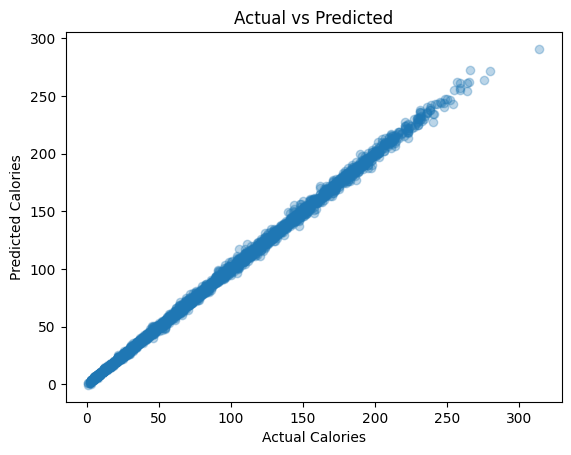

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, test_data_prediction, alpha=0.3)
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Actual vs Predicted')
plt.show()

In [22]:
import pandas as pd

# 1. Prepare new data (Let's imagine a person)
# Order: Gender, Age, Height, Weight, Duration, Heart_Rate, Body_Temp
new_person = pd.DataFrame([[0, 25, 175.0, 80.0, 20.0, 110.0, 40.0]], 
                        columns=X.columns)

# 2. Prediction
prediction = model.predict(new_person)

print(f"The predicted burned calories for this person is: {prediction[0]:.2f} Calories")

The predicted burned calories for this person is: 125.44 Calories


In [23]:
import pandas as pd

print("--- Calories Burn Prediction System ---")

# Getting inputs from the user
gender = int(input("Enter Gender (0 for male, 1 for female): "))
age = float(input("Enter Age: "))
height = float(input("Enter Height (cm): "))
weight = float(input("Enter Weight (kg): "))
duration = float(input("Enter Exercise Duration (min): "))
heart_rate = float(input("Enter Heart Rate (bpm): "))
body_temp = float(input("Enter Body Temperature (C): "))

# Organizing data into a DataFrame with the correct column names
input_data = pd.DataFrame([[gender, age, height, weight, duration, heart_rate, body_temp]], 
                        columns=X.columns)

# Making the prediction using our trained model
user_prediction = model.predict(input_data)

print("-" * 40)
print(f"Estimated Calories Burned: {user_prediction[0]:.2f} kcal")
print("-" * 40)

--- Calories Burn Prediction System ---
----------------------------------------
Estimated Calories Burned: 32.93 kcal
----------------------------------------


In [24]:
# Save the model to a file
model.save_model("calories_model.json")
print("Model saved successfully as calories_model.json")

Model saved successfully as calories_model.json
